In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

BASE_DIR = Path.cwd().parent
df = pd.read_csv(BASE_DIR / 'exports' / 'customer_rmf.csv')

# 1. Segment Distribution

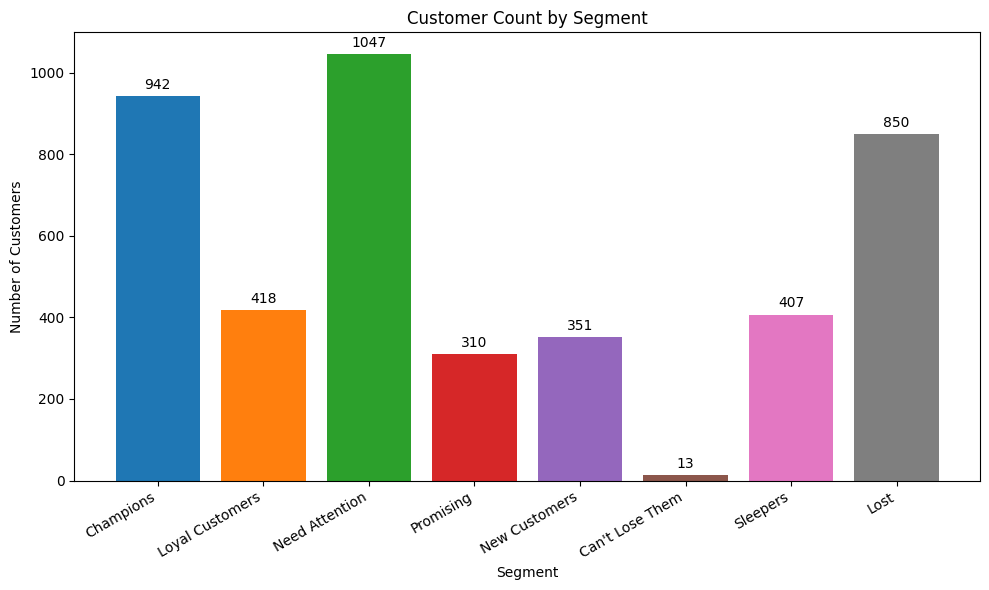

In [3]:
segment_order = [
    'Champions', 'Loyal Customers', 'Need Attention',
    'Promising', 'New Customers', "Can't Lose Them",
    'Sleepers', 'Lost'
]

seg_counts = df['Segment'].value_counts().reindex(segment_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(seg_counts.index, seg_counts.values, color=sns.color_palette('tab10', len(seg_counts)))
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Customer Count by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# 2. R / F / M Score Distributions

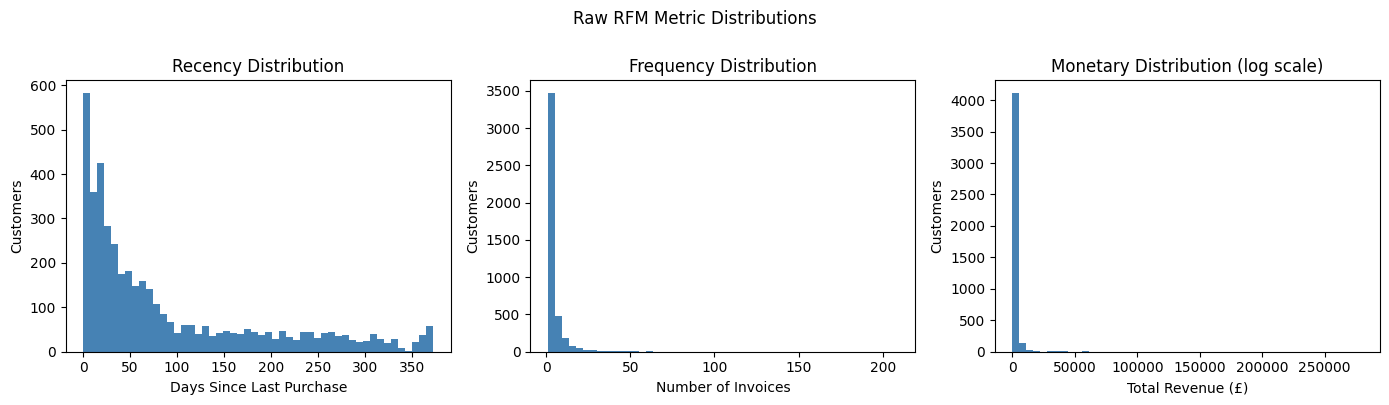

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Recency'], bins=50, color='steelblue', edgecolor='none')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Customers')

axes[1].hist(df['Frequency'], bins=50, color='steelblue', edgecolor='none')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Invoices')
axes[1].set_ylabel('Customers')

axes[2].hist(df['Monetary'], bins=50, color='steelblue', edgecolor='none')
axes[2].set_title('Monetary Distribution (log scale)')
axes[2].set_xlabel('Total Revenue (£)')
axes[2].set_ylabel('Customers')

plt.suptitle('Raw RFM Metric Distributions', y=1)
plt.tight_layout()
plt.show()

# 3. RFM Metric Distributions by Segment

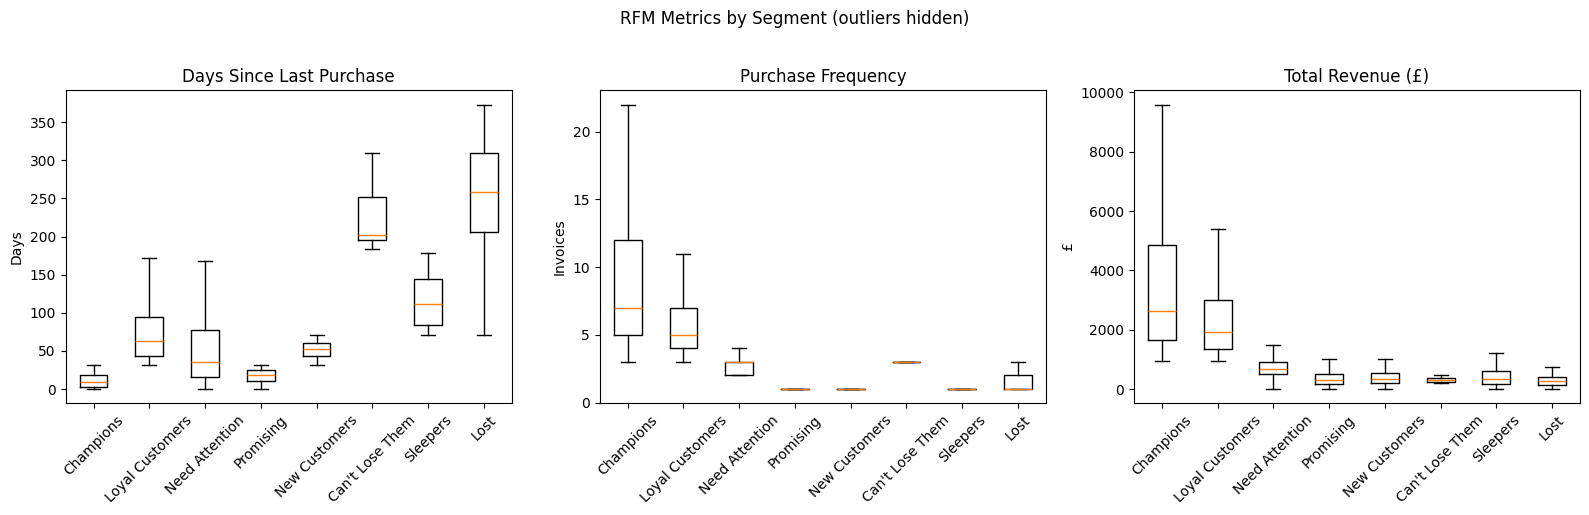

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('Recency',   'Days Since Last Purchase', 'Days'),
    ('Frequency', 'Purchase Frequency',   'Invoices'),
    ('Monetary',  'Total Revenue (£)',           '£')
]

present_segs = [s for s in segment_order if s in df['Segment'].unique()]

for ax, (col, title, ylabel) in zip(axes, metrics):
    data = [df.loc[df['Segment'] == seg, col].values for seg in present_segs]
    ax.boxplot(data, tick_labels=present_segs, showfliers=False)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('RFM Metrics by Segment (outliers hidden)', y=1.02)
plt.tight_layout()
plt.show()

# 4. Recency vs Monetary Scatter

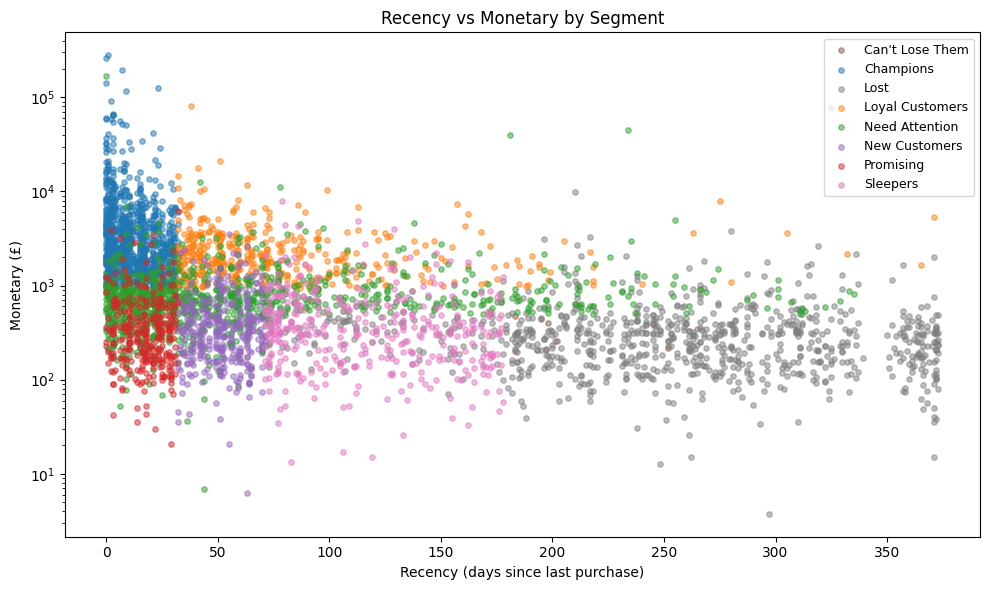

In [6]:
palette = dict(zip(segment_order, sns.color_palette('tab10', len(segment_order))))

fig, ax = plt.subplots(figsize=(10, 6))

for seg, grp in df.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Monetary'], label=seg,
               alpha=0.5, s=15, color=palette.get(seg))

ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Monetary (£)')
ax.set_title('Recency vs Monetary by Segment')
ax.set_yscale('log')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# 5. Concentration by Segment

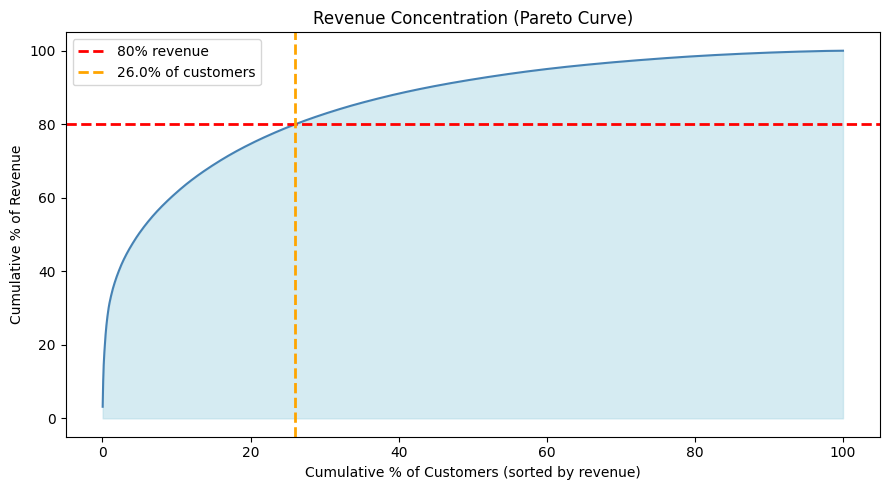

26.0% of customers generate 80% of total revenue


In [7]:
df_sorted = df.sort_values('Monetary', ascending=False).reset_index(drop=True)
df_sorted['CumulativeRevenuePct'] = df_sorted['Monetary'].cumsum() / df_sorted['Monetary'].sum() * 100
df_sorted['CustomerPct'] = (df_sorted.index + 1) / len(df_sorted) * 100

# Find the customer % that accounts for 80% of revenue
threshold_80 = df_sorted.loc[df_sorted['CumulativeRevenuePct'] >= 80, 'CustomerPct'].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sorted['CustomerPct'], df_sorted['CumulativeRevenuePct'], color='steelblue')
ax.axhline(80, color='red', linestyle='--', linewidth=2, label='80% revenue')
ax.axvline(threshold_80, color='orange', linestyle='--', linewidth=2,
           label=f'{threshold_80:.1f}% of customers')
ax.fill_between(df_sorted['CustomerPct'], df_sorted['CumulativeRevenuePct'], alpha=0.5, color='lightblue')
ax.set_xlabel('Cumulative % of Customers (sorted by revenue)')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Revenue Concentration (Pareto Curve)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'{threshold_80:.1f}% of customers generate 80% of total revenue')

# 6. Revenue Share by Segment

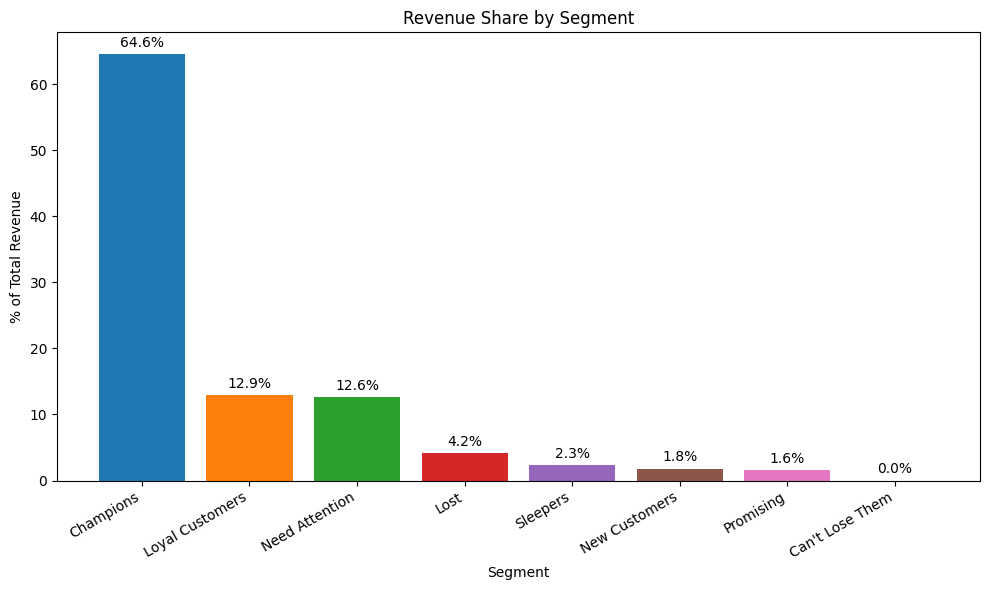

In [11]:
seg_revenue = (df.groupby('Segment')['Monetary']
                 .sum()
                 .reindex(segment_order, fill_value=0)
                 .sort_values(ascending=False))

seg_revenue_pct = (seg_revenue / seg_revenue.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(seg_revenue_pct.index, seg_revenue_pct.values,
              color=sns.color_palette('tab10', len(seg_revenue_pct)))
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Revenue Share by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('% of Total Revenue')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()